# Adaptive Lifelong IRL for Human-Robot Collaboration

Thin experiment notebook over the `src/hrc_lifelong/` package.
Use this notebook to configure benchmark profiles, run the continual-learning suites, export artifacts, and inspect publication-oriented summaries.

## Cell 1: Setup and Domain Bootstrap

In [1]:
from pathlib import Path
import os
import random
import sys

import numpy as np

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROFILE = "paper"
RANDOM_SEED = 42

# NOTEBOOK_SCALE:
# - "debug": fast + stable interactive iteration
# - "paper": full run for final tables/figures
NOTEBOOK_SCALE = "debug"

PAPER_SEEDS = (7, 13, 21, 42, 84, 101, 123, 211, 307, 509)
DEBUG_SEEDS = (42, 84)
BENCHMARK_SEEDS = DEBUG_SEEDS if NOTEBOOK_SCALE == "debug" else PAPER_SEEDS

SYSTEMS = ("AdaptiveLinearDecay", "FixedLinearDecay", "UniformWeight", "NoReplay")
DOMAINS = ("kitchen",)
WRITE_ARTIFACTS = False
EXPORT_DIR = ROOT / "artifacts" / PROFILE

# Debug printing controls (prevents notebook/front-end overload).
DEBUG_VERBOSE_PRINT = True
DEBUG_VERBOSE_SYSTEM = "AdaptiveLinearDecay"
DEBUG_VERBOSE_SEED = BENCHMARK_SEEDS[0] if BENCHMARK_SEEDS else None
DEBUG_MAX_VERBOSE_EPISODES = 24

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

from hrc_lifelong.benchmark import (
    BenchmarkConfig,
    BenchmarkRunner,
    build_default_assets,
    build_scenario_suites,
    build_decay_timeline,
    build_episode_debug_rows,
    build_paired_system_deltas,
    export_benchmark_artifacts,
    plot_benchmark_summaries,
    plot_system_dashboard,
    print_benchmark_summary,
    summarize_decay_effects,
    summarize_results,
)

library, trajectory_builder, preference_engine = build_default_assets()
config = BenchmarkConfig.for_profile(
    PROFILE,
    export_dir=EXPORT_DIR,
    seeds=BENCHMARK_SEEDS,
    systems=SYSTEMS,
    domains=DOMAINS,
)
all_suites = build_scenario_suites(profile=config.profile, domains=config.domains, seed=RANDOM_SEED)
print("Available suites:", [suite.name for suite in all_suites])
suites = tuple(suite for suite in all_suites if suite.name in ("kitchen_core", "kit_dec_dyn"))
if not any(suite.name == "kit_dec_dyn" for suite in suites):
    raise RuntimeError("kit_dec_dyn suite was not selected. Check build_scenario_suites output.")

print(f"Profile: {PROFILE}")
print(f"Notebook scale: {NOTEBOOK_SCALE}")
print("Seeds:", BENCHMARK_SEEDS)
print("Systems:", SYSTEMS)
print("Domains:", DOMAINS)
print(f"Recipes loaded: {len(library.all())}")
print(f"Preference rules loaded: {len(preference_engine.rules)}")
print("Suites:", [suite.name for suite in suites])



Available suites: ['kitchen_core', 'kitchen_preference_axes', 'kitchen_multi_combo', 'kitchen_longitudinal', 'kit_dec_dyn']
Profile: paper
Notebook scale: debug
Seeds: (42, 84)
Systems: ('AdaptiveLinearDecay', 'FixedLinearDecay', 'UniformWeight', 'NoReplay')
Domains: ('kitchen',)
Recipes loaded: 15
Preference rules loaded: 9
Suites: ['kitchen_core', 'kit_dec_dyn']


## Cell 2: Feature / Trainer Bootstrap

In [2]:
from hrc_lifelong.irl import FeatureExtractor, FeatureExtractorConfig, IRLTrainerConfig

feature_config = FeatureExtractorConfig()
if NOTEBOOK_SCALE == "debug":
    trainer_config = IRLTrainerConfig(
        n_iterations=2,
        max_rollouts=12,
        min_rollouts=6,
        max_vi_steps=12,
        rollout_horizon=12,
        early_stop_patience=2,
    )
else:
    trainer_config = IRLTrainerConfig(
        n_iterations=4,
        max_rollouts=20,
        min_rollouts=10,
        max_vi_steps=20,
        rollout_horizon=20,
        early_stop_patience=3,
    )
feature_extractor = FeatureExtractor(config=feature_config)
runner = BenchmarkRunner(
    config=config,
    suites=suites,
    feature_config=feature_config,
    trainer_config=trainer_config,
)

print(f"Engineered feature dimension: {feature_extractor.n_features}")
print(trainer_config)



Engineered feature dimension: 287
IRLTrainerConfig(n_iterations=2, learning_rate=0.05, temperature=0.5, gamma=0.9, l2_weight=0.01, max_rollouts=12, min_rollouts=6, max_vi_steps=12, rollout_horizon=12, early_stop_patience=2)


## Benchmark Execution

In [3]:
results = runner.run()
print_benchmark_summary(results)

suite_names = sorted({result.suite_name for result in results})
print("Executed suites:", suite_names)
if "kit_dec_dyn" not in suite_names:
    raise RuntimeError("Expected suite 'kit_dec_dyn' was not executed.")
for suite_name in suite_names:
    suite_rows = [result for result in results if result.suite_name == suite_name]
    print(f"  {suite_name}: {len(suite_rows)} runs")

if WRITE_ARTIFACTS:
    export_path = export_benchmark_artifacts(results, config.export_dir)
    print("Artifacts exported to:", export_path)
else:
    print("Artifact export disabled (WRITE_ARTIFACTS=False).")


# Continual HRC Benchmark Report

## System Summary
- **AdaptiveLinearDecay**: novelty 90.5%, next-action 65.7% -> 92.6%, held-out 64.5%, retention 92.1%, stream recall 88.5%, max forgetting gap 0.20, preference F1 86.0%
- **FixedLinearDecay**: novelty 90.5%, next-action 65.4% -> 92.3%, held-out 61.4%, retention 91.6%, stream recall 88.5%, max forgetting gap 0.20, preference F1 86.0%
- **NoReplay**: novelty 90.5%, next-action 67.3% -> 92.4%, held-out 57.5%, retention 92.1%, stream recall 92.0%, max forgetting gap 0.17, preference F1 86.0%
- **UniformWeight**: novelty 90.5%, next-action 68.2% -> 92.3%, held-out 65.6%, retention 93.7%, stream recall 91.8%, max forgetting gap 0.08, preference F1 86.0%

## Baseline Comparison
- **AdaptiveLinearDecay**: stream recall mean 89.5%, final 88.5%, minimum 85.4%, catastrophic forgetting rate 0.0%, mean active/archive families 3.63/5.35
- **FixedLinearDecay**: stream recall mean 89.2%, final 88.5%, minimum 85.4%, catastrophic forgetting rate 0.0%, 

## Comparative Figure

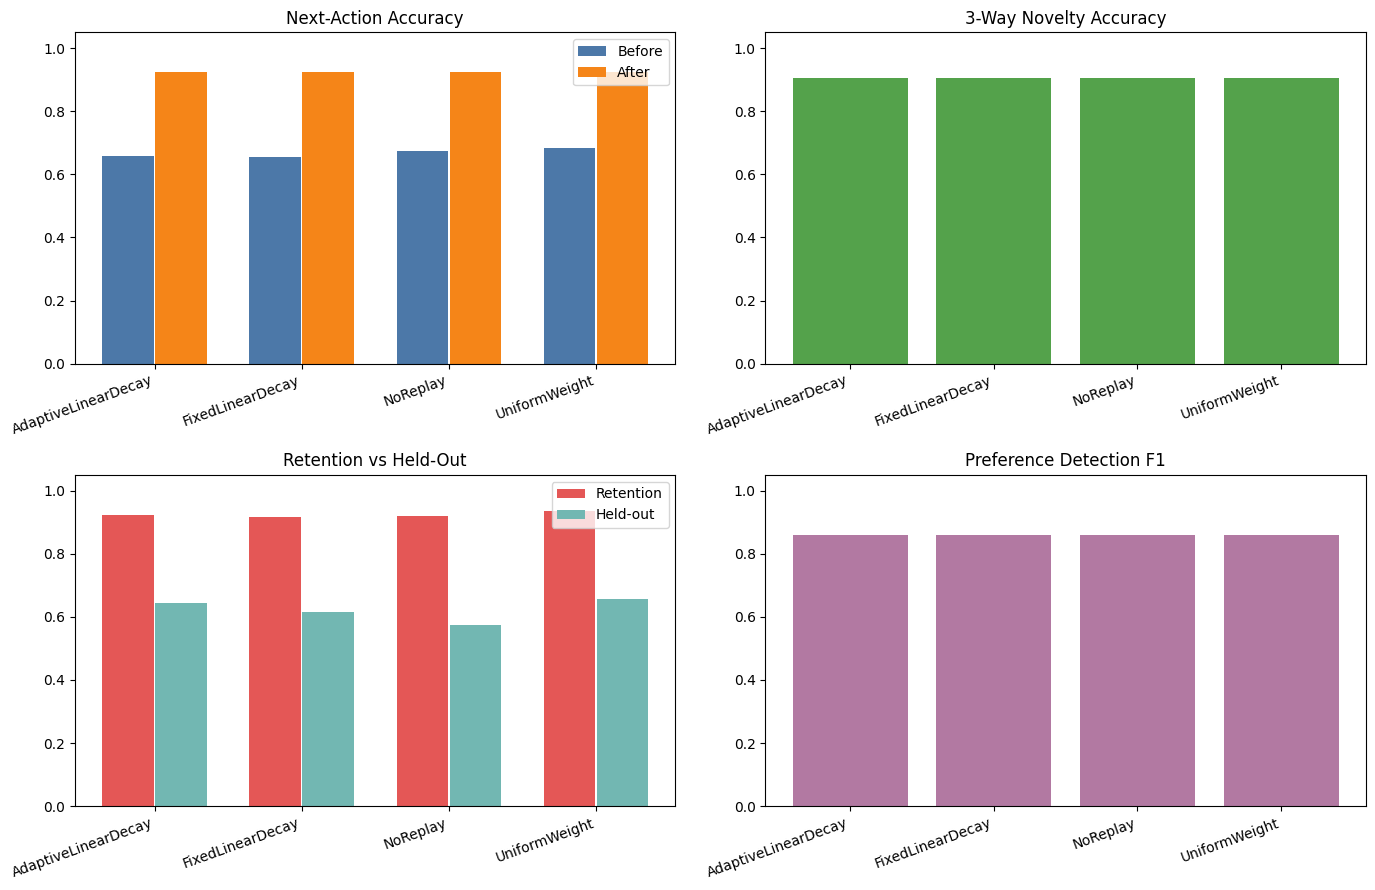

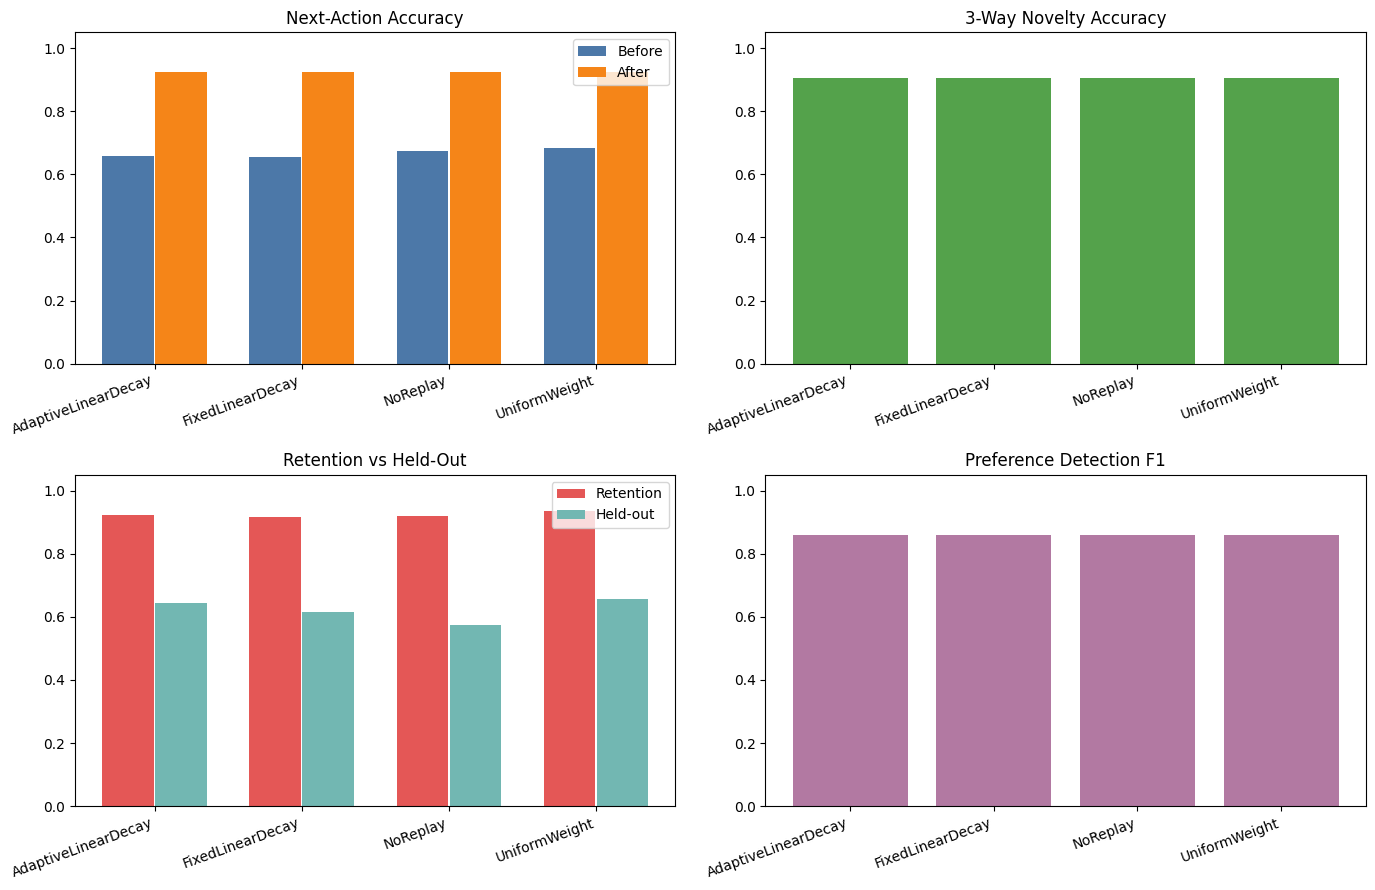

In [4]:
comparison_fig = plot_benchmark_summaries(results)
comparison_fig

## System Dashboard

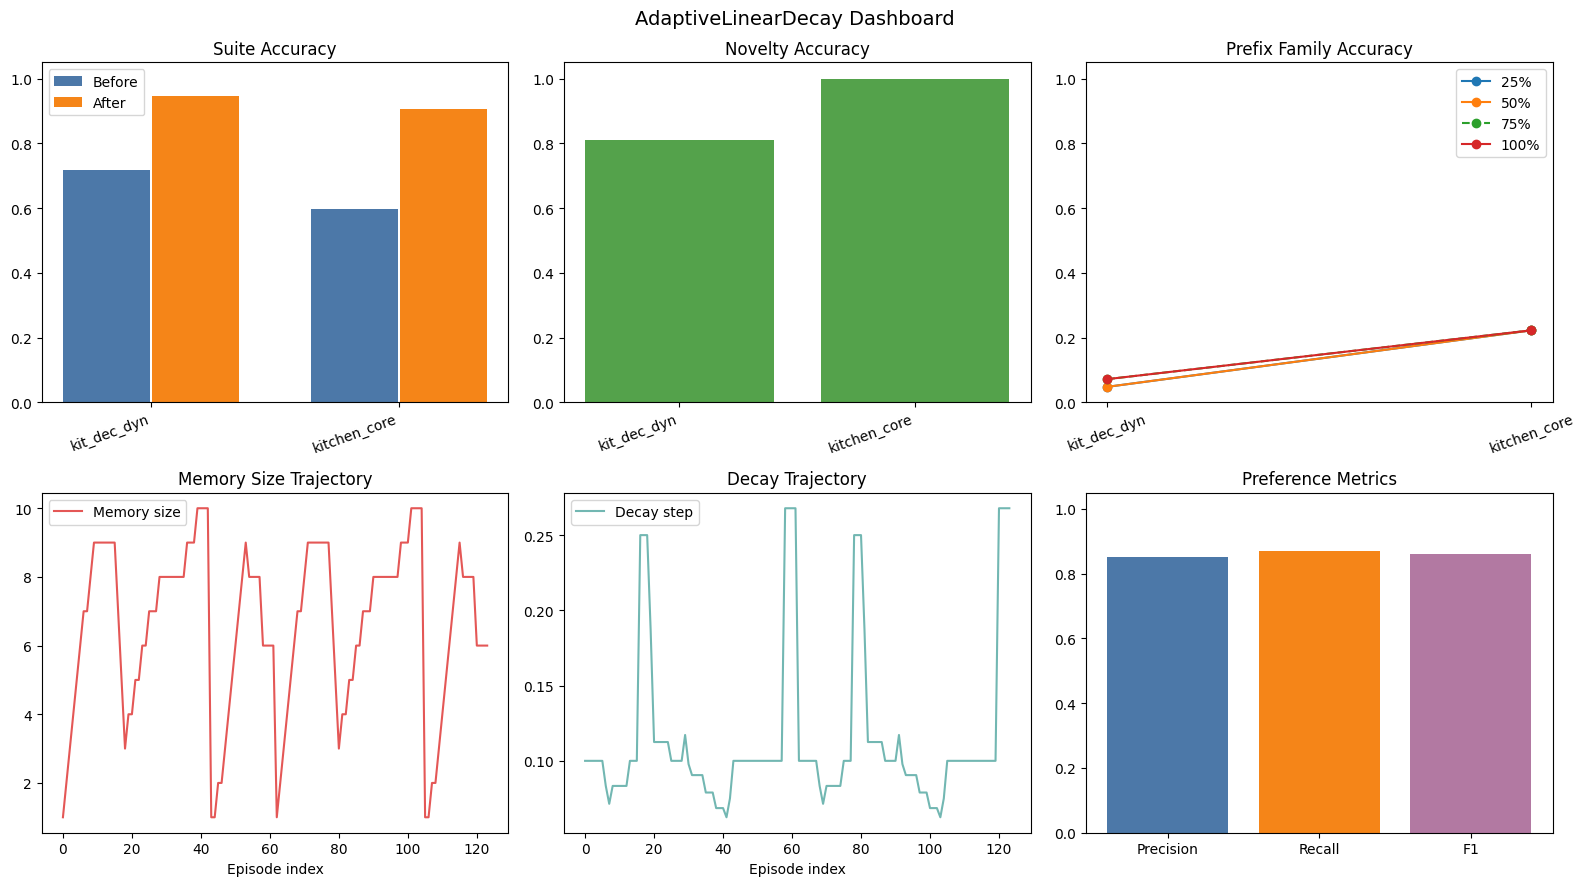

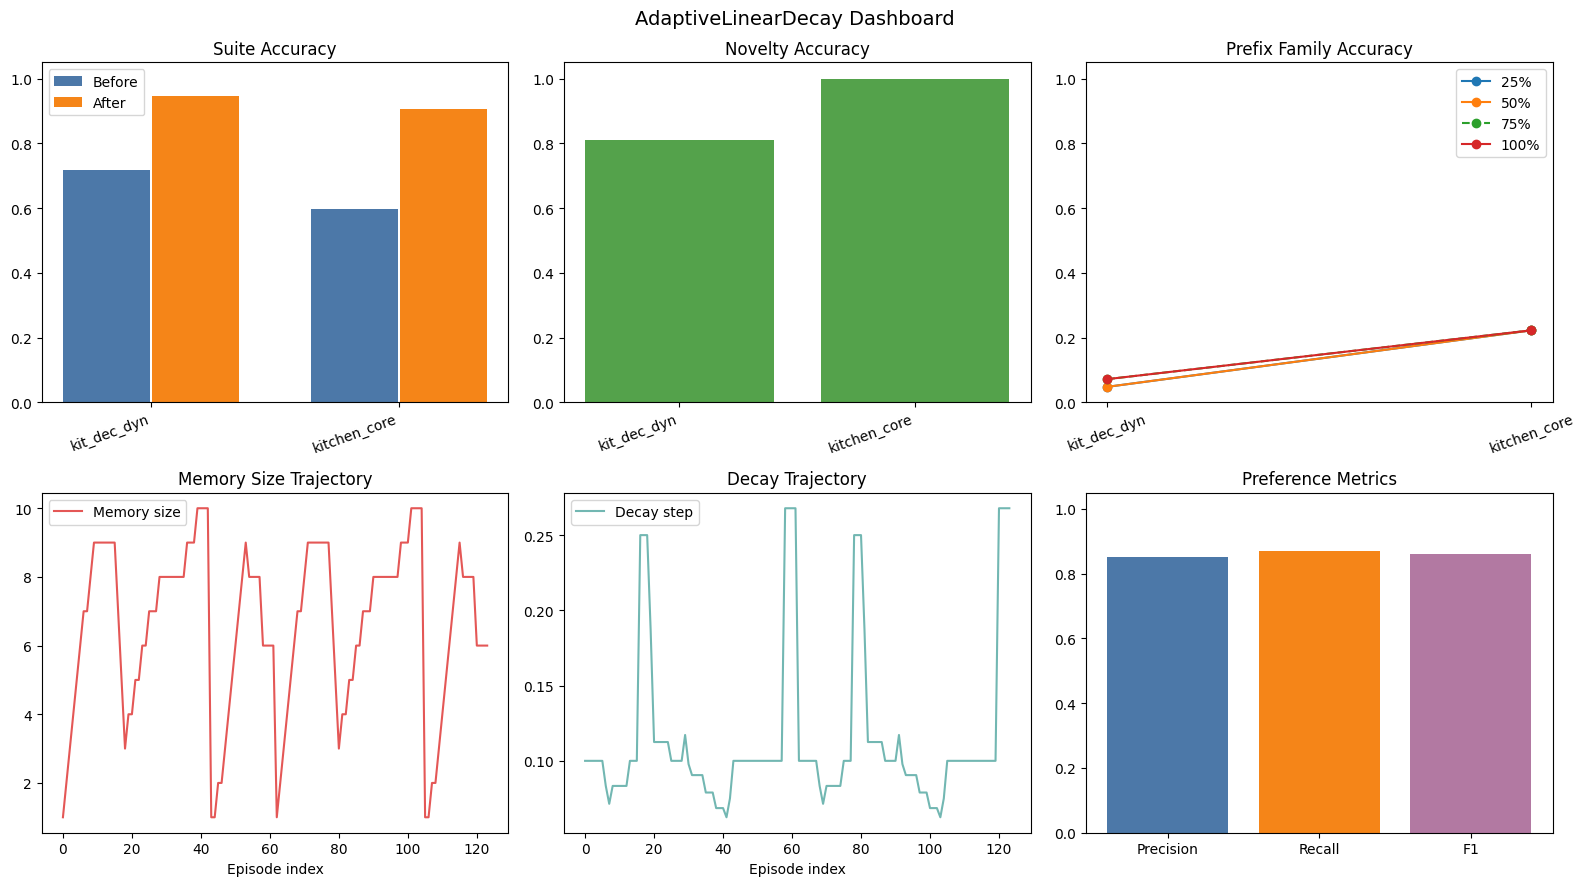

In [5]:
system_name = sorted({result.system_name for result in results})[0]
system_results = tuple(result for result in results if result.system_name == system_name)
dashboard = plot_system_dashboard(system_results)
dashboard

## Appendix Inspection

In [6]:
summary_rows = summarize_results(results)
summary_rows


[{'system_name': 'AdaptiveLinearDecay',
  'n_runs': 4,
  'novelty_accuracy_mean': 0.9047619047619048,
  'novelty_accuracy_std': 0.109971479845643,
  'next_action_before_mean': 0.6572896058584464,
  'next_action_before_std': 0.06997376146738257,
  'next_action_after_mean': 0.9258546123763515,
  'next_action_after_std': 0.022031236842501734,
  'adaptation_gain_mean': 0.2995676903611686,
  'adaptation_gain_std': 0.08372894955727365,
  'held_out_accuracy_mean': 0.6452173913043479,
  'held_out_accuracy_std': 0.0,
  'retention_all_seen_mean': 0.9214018087855298,
  'retention_all_seen_std': 0.039576806369778214,
  'resurfacing_recovery_mean': 0.9539345142243693,
  'resurfacing_recovery_std': 0.02111682627084335,
  'preference_precision_mean': 0.8513513513513513,
  'preference_precision_std': 0.015604061329449378,
  'preference_recall_mean': 0.8690521507422916,
  'preference_recall_std': 0.004835061257012415,
  'preference_f1_mean': 0.8600186393289841,
  'preference_f1_std': 0.0055959392353888

## Kitchen Decay Dynamics (Timeline + Effects)

In [7]:
import pandas as pd

decay_timeline_rows = build_decay_timeline(results, domain="kitchen", suite_name="kit_dec_dyn")
decay_effect_rows = summarize_decay_effects(results, domain="kitchen", suite_name="kit_dec_dyn")
paired_delta_rows = build_paired_system_deltas(results, domain="kitchen", suite_name="kit_dec_dyn")

if not decay_timeline_rows:
    raise RuntimeError("No rows for suite 'kit_dec_dyn'. Confirm benchmark execution included that suite.")

decay_timeline_df = pd.DataFrame(decay_timeline_rows)
decay_effect_df = pd.DataFrame(decay_effect_rows)
paired_delta_df = pd.DataFrame(paired_delta_rows)

print("Decay timeline rows:", len(decay_timeline_df))
decay_effect_df


Decay timeline rows: 344


,system_name,domain,suite_name,n_runs,mean_decay_step_mean,mean_decay_step_std,decay_volatility_mean,decay_volatility_std,prune_rate_mean,prune_rate_std,resurfacing_recovery_mean,resurfacing_recovery_std,long_gap_resurfacing_recovery_mean,long_gap_resurfacing_recovery_std,stream_recall_final_mean,stream_recall_final_std,stream_recall_min_mean,stream_recall_min_std,max_forgetting_gap_mean,max_forgetting_gap_std
0,AdaptiveLinearDecay,kitchen,kit_dec_dyn,2,0.105444,0.0,0.044763,0.0,0.071429,0.0,0.085695,1.387779e-17,0.10,0.000000,0.884700,0.000000,0.853768,0.005612,0.200000,0.000000
1,FixedLinearDecay,kitchen,kit_dec_dyn,2,0.100000,0.0,0.000000,0.0,0.000000,0.0,0.087670,1.222160e-03,0.07,0.014142,0.884700,0.000000,0.853768,0.005612,0.200000,0.000000
2,NoReplay,kitchen,kit_dec_dyn,2,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.028519,8.729713e-03,0.00,0.000000,0.920414,0.000000,0.889710,0.000351,0.166667,0.000000
3,UniformWeight,kitchen,kit_dec_dyn,2,0.000000,0.0,0.000000,0.0,0.000000,0.0,-0.004136,4.364857e-04,0.00,0.000000,0.918123,0.006861,0.918123,0.006861,0.083333,0.039284


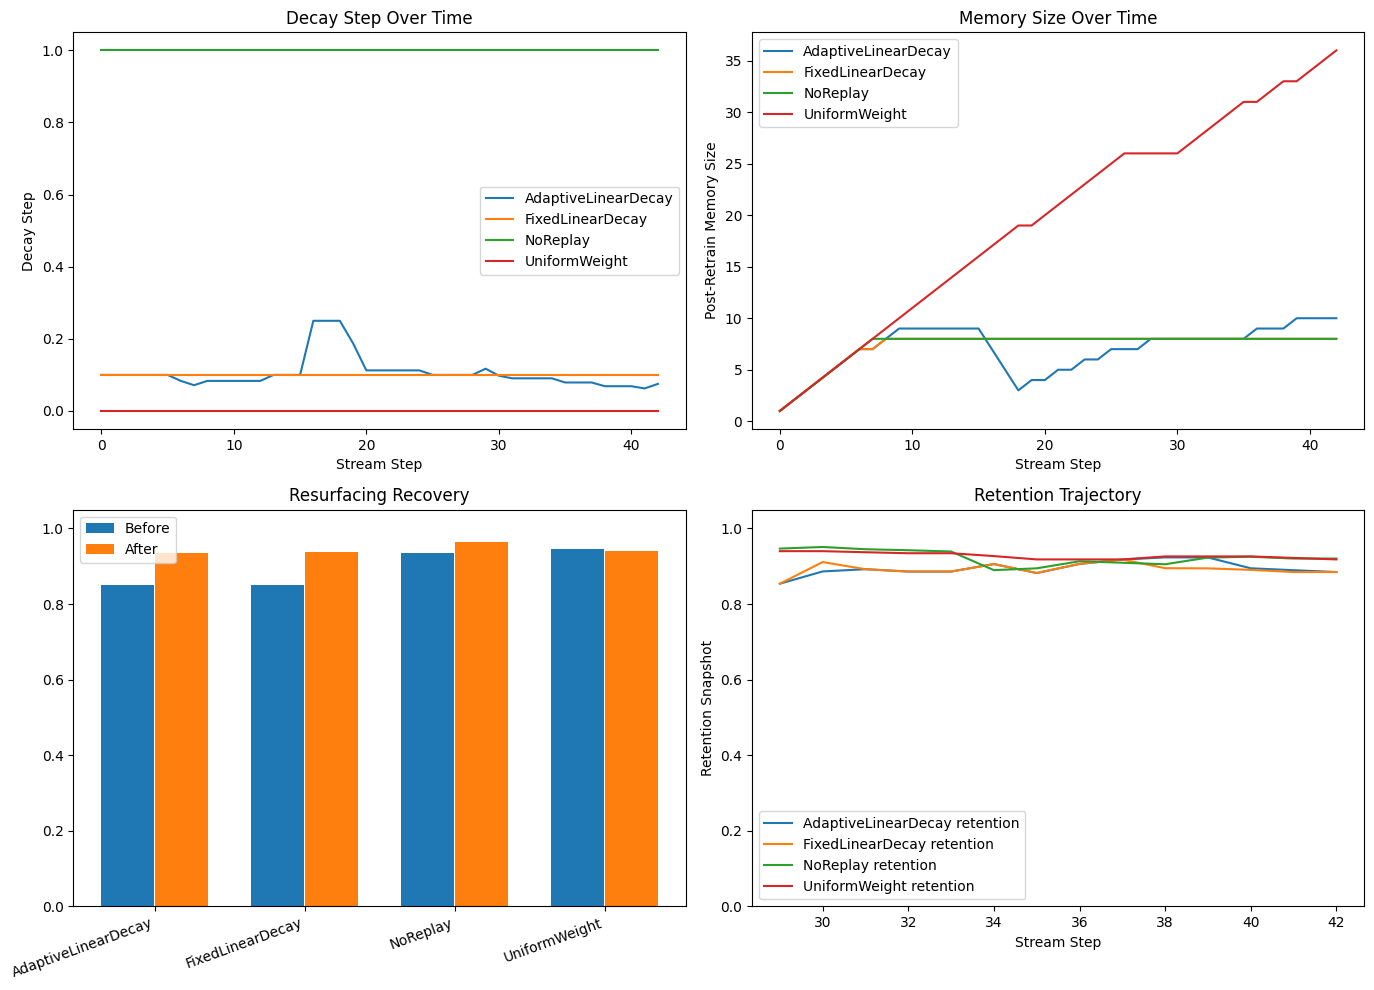

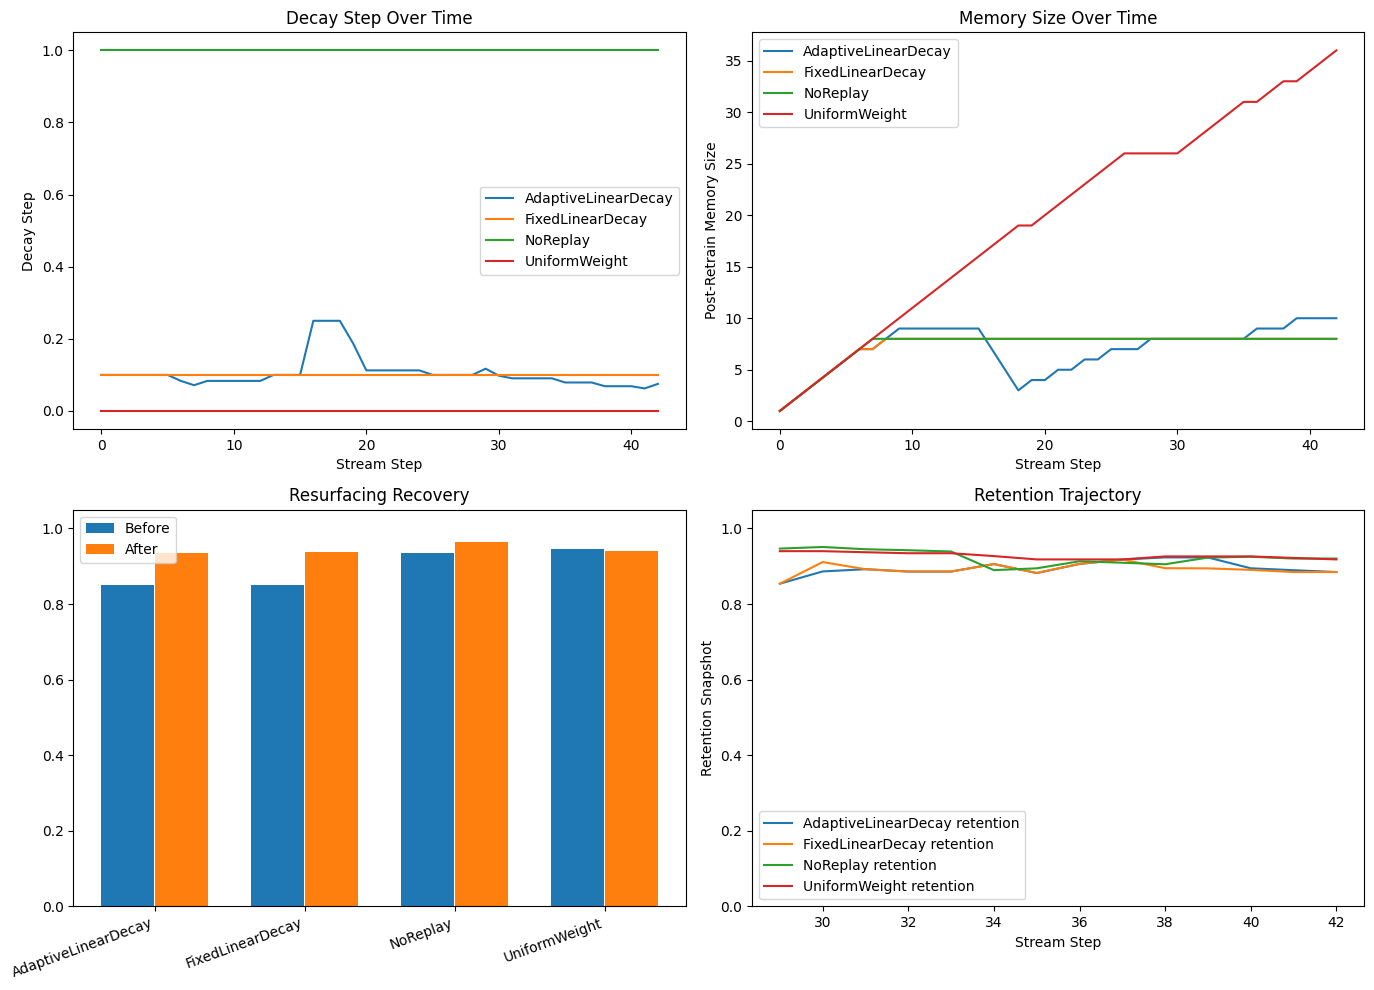

In [8]:
import matplotlib.pyplot as plt

plot_df = decay_timeline_df.copy()
plot_df = plot_df.dropna(subset=["stream_step"])
plot_df["stream_step"] = plot_df["stream_step"].astype(int)

agg = plot_df.groupby(["system_name", "stream_step"], as_index=False).agg(
    decay_step=("decay_step", "mean"),
    memory_size=("post_memory_size", "mean"),
    active_families=("active_family_count", "mean"),
    retention=("retention_snapshot", "mean"),
    forgetting=("max_forgetting_gap", "mean"),
)

resurfacing = plot_df[plot_df["resurfacing_marker"] == True].copy()
resurfacing["after_eval"] = resurfacing["post_retrain_retest_accuracy"].fillna(resurfacing["accuracy_after"])
resurfacing_bar = resurfacing.groupby("system_name", as_index=False).agg(
    before=("accuracy_before", "mean"),
    after=("after_eval", "mean"),
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for system_name, group in agg.groupby("system_name"):
    axes[0, 0].plot(group["stream_step"], group["decay_step"], label=system_name)
axes[0, 0].set_title("Decay Step Over Time")
axes[0, 0].set_xlabel("Stream Step")
axes[0, 0].set_ylabel("Decay Step")
axes[0, 0].legend()

for system_name, group in agg.groupby("system_name"):
    axes[0, 1].plot(group["stream_step"], group["memory_size"], label=system_name)
axes[0, 1].set_title("Memory Size Over Time")
axes[0, 1].set_xlabel("Stream Step")
axes[0, 1].set_ylabel("Post-Retrain Memory Size")
axes[0, 1].legend()

x = range(len(resurfacing_bar))
axes[1, 0].bar([i - 0.18 for i in x], resurfacing_bar["before"], width=0.35, label="Before")
axes[1, 0].bar([i + 0.18 for i in x], resurfacing_bar["after"], width=0.35, label="After")
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(list(resurfacing_bar["system_name"]), rotation=20, ha="right")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title("Resurfacing Recovery")
axes[1, 0].legend()

for system_name, group in agg.groupby("system_name"):
    axes[1, 1].plot(group["stream_step"], group["retention"], label=f"{system_name} retention")
axes[1, 1].set_title("Retention Trajectory")
axes[1, 1].set_xlabel("Stream Step")
axes[1, 1].set_ylabel("Retention Snapshot")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()

fig.tight_layout()
fig


In [9]:
if paired_delta_df.empty:
    print("No paired deltas generated for kit_dec_dyn.")
else:
    display(paired_delta_df.sort_values(["baseline_system", "metric"]).reset_index(drop=True))

DEBUG_DOMAIN = "kitchen"
DEBUG_SUITE = "kit_dec_dyn"
DEBUG_SYSTEM = DEBUG_VERBOSE_SYSTEM

debug_rows = build_episode_debug_rows(
    results,
    domain=DEBUG_DOMAIN,
    suite_name=DEBUG_SUITE,
    system_name=DEBUG_SYSTEM,
)
if not debug_rows:
    raise RuntimeError(f"No debug rows found for {DEBUG_SYSTEM} on {DEBUG_SUITE}.")

debug_df = pd.DataFrame(debug_rows).sort_values(["seed", "episode_index"]).reset_index(drop=True)

# Short tags for tighter display.
debug_df["expected_decision"] = debug_df["expected_decision"].replace({"preference_update": "pref_up"})
debug_df["predicted_decision"] = debug_df["predicted_decision"].replace({"preference_update": "pref_up"})

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.width", 260)

def _fmt(value, digits=3):
    if pd.isna(value):
        return "na"
    try:
        return f"{float(value):.{digits}f}"
    except Exception:
        return str(value)

debug_view_cols = [
    "seed",
    "episode_index",
    "timeline_role",
    "phase",
    "family",
    "variant",
    "expected_decision",
    "predicted_decision",
    "what_changed",
    "prior_memory_size",
    "post_memory_size",
    "prior_decay_step",
    "post_decay_step",
    "decay_branch",
    "decay_n_active_families",
    "decay_size_factor",
    "decay_gap_count",
    "decay_avg_gap_steps",
    "decay_avg_gap_cycles",
    "decay_target_pre_size",
    "decay_target_post_size",
    "decay_explanation",
    "active_family_weights",
    "active_variant_weights",
    "post_session_active_dataset",
]

display(debug_df[debug_view_cols])

# Show one concise table with test-set recipe steps for chosen seed/system.
seed_focus_df = debug_df[debug_df["seed"] == DEBUG_VERBOSE_SEED].copy() if DEBUG_VERBOSE_SEED is not None else debug_df.copy()
steps_cols = [
    "seed",
    "episode_index",
    "family",
    "variant",
    "expected_decision",
    "predicted_decision",
    "post_decay_step",
    "active_variant_weights",
    "post_session_active_dataset",
    "test_recipe_steps",
]
display(seed_focus_df[steps_cols].head(DEBUG_MAX_VERBOSE_EPISODES))

if DEBUG_VERBOSE_PRINT:
    print("\nDetailed per-episode debug (bounded to avoid kernel/front-end crashes):")
    print(f"system={DEBUG_SYSTEM} | seed={DEBUG_VERBOSE_SEED} | max_episodes={DEBUG_MAX_VERBOSE_EPISODES}")
    shown = 0
    for row in seed_focus_df.itertuples(index=False):
        if shown >= DEBUG_MAX_VERBOSE_EPISODES:
            break
        shown += 1
        print(
            f"\nseed={row.seed} | ep={row.episode_index} | role={row.timeline_role} | "
            f"family={row.family} | variant={row.variant}"
        )
        print(f"decision: {row.expected_decision}->{row.predicted_decision} | change: {row.what_changed}")
        print(f"decay_explanation: {row.decay_explanation}")
        print(
            "decay: "
            f"{_fmt(row.prior_decay_step)}->{_fmt(row.post_decay_step)} | branch={row.decay_branch} "
            f"families={row.decay_n_active_families} | size_factor={_fmt(row.decay_size_factor)} | "
            f"gaps={row.decay_gap_count} | avg_gap_steps={_fmt(row.decay_avg_gap_steps)} | "
            f"avg_gap_cycles={_fmt(row.decay_avg_gap_cycles)} | "
            f"target_pre={_fmt(row.decay_target_pre_size)} | target_post={_fmt(row.decay_target_post_size)}"
        )
        print(f"active_dataset_size={row.post_session_dataset_size}")
        print(f"active_family_weights: {row.active_family_weights}")
        print(f"active_variant_weights: {row.active_variant_weights}")
        print(f"active_variant_dataset: {row.post_session_active_dataset or 'none'}")
        print("test_recipe_steps:")
        print(row.test_recipe_steps)



,domain,suite_name,anchor_system,baseline_system,metric,n_pairs,delta_mean,delta_std,ci95_low,ci95_high
0,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,long_gap_resurfacing_recovery,2,0.030000,0.014142,0.010400,0.049600
1,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,max_forgetting_gap,2,0.000000,0.000000,0.000000,0.000000
2,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,mean_decay_step,2,0.005444,0.000000,0.005444,0.005444
3,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,prune_rate,2,0.071429,0.000000,0.071429,0.071429
4,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,stream_recall_final,2,0.000000,0.000000,0.000000,0.000000
5,kitchen,kit_dec_dyn,AdaptiveLinearDecay,FixedLinearDecay,stream_recall_min,2,0.000000,0.000000,0.000000,0.000000
6,kitchen,kit_dec_dyn,AdaptiveLinearDecay,NoReplay,long_gap_resurfacing_recovery,2,0.100000,0.000000,0.100000,0.100000
7,kitchen,kit_dec_dyn,AdaptiveLinearDecay,NoReplay,max_forgetting_gap,2,0.033333,0.000000,0.033333,0.033333
8,kitchen,kit_dec_dyn,AdaptiveLinearDecay,NoReplay,mean_decay_step,2,-0.894556,0.000000,-0.894556,-0.894556
9,kitchen,kit_dec_dyn,AdaptiveLinearDecay,NoReplay,prune_rate,2,0.071429,0.000000,0.071429,0.071429


,seed,episode_index,timeline_role,phase,family,variant,expected_decision,predicted_decision,what_changed,prior_memory_size,post_memory_size,prior_decay_step,post_decay_step,decay_branch,decay_n_active_families,decay_size_factor,decay_gap_count,decay_avg_gap_steps,decay_avg_gap_cycles,decay_target_pre_size,decay_target_post_size,decay_explanation,active_family_weights,active_variant_weights,post_session_active_dataset
0,42,1,seed_demo,seed,tomato_onion_soup,tomato_onion_soup/base,new_recipe,new_recipe,Seeded family into memory; post-demo retest=100.0%.,0,1,0.100000,0.100000,adaptive_without_resurfacing,1,1.000000,0,NaN,NaN,0.100000,0.100000,decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=1 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100,0.900-tom_oni_soup,0.900-tomato_onion_soup/base,tomato_onion_soup/base=0.900
1,42,2,new_recipe_demo,online,boiled_eggs,boiled_eggs/late_everything,new_recipe,new_recipe,Queued and retrained; retest 38.9%->100.0%; memory 1->2; edits=no sequence edit.,1,2,0.100000,0.100000,adaptive_without_resurfacing,1,1.000000,0,NaN,NaN,0.100000,0.100000,decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=1 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100,"1.000-fam_001, 0.800-tom_oni_soup",1.000-family_001/variant_01; 0.800-tomato_onion_soup/base,family_001/variant_01=1.000; tomato_onion_soup/base=0.800
2,42,3,new_recipe_demo,online,boiled_rice,boiled_rice/late_everything,new_recipe,new_recipe,Queued and retrained; retest 30.0%->95.0%; memory 2->3; edits=no sequence edit.,2,3,0.100000,0.100000,adaptive_without_resurfacing,2,1.000000,0,NaN,NaN,0.100000,0.100000,decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=2 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100,"1.000-fam_002, 0.900-fam_001, 0.700-tom_oni_soup",1.000-family_002/variant_01; 0.900-family_001/variant_01; 0.700-tomato_onion_soup/base,family_001/variant_01=0.900; family_002/variant_01=1.000; tomato_onion_soup/base=0.700
3,42,4,new_recipe_demo,online,grilled_steak,grilled_steak/late_everything,new_recipe,new_recipe,Queued and retrained; retest 15.0%->95.0%; memory 3->4; edits=no sequence edit.,3,4,0.100000,0.100000,adaptive_without_resurfacing,3,1.000000,0,NaN,NaN,0.100000,0.100000,decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=3 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100,"1.000-fam_003, 0.900-fam_002, 0.800-fam_001, 0.600-tom_oni_soup",1.000-family_003/variant_01; 0.900-family_002/variant_01; 0.800-family_001/variant_01; 0.600-tomato_onion_soup/base,family_001/variant_01=0.800; family_002/variant_01=0.900; family_003/variant_01=1.000; tomato_onion_soup/base=0.600
4,42,5,new_recipe_demo,online,mushroom_soup,mushroom_soup/late_everything,new_recipe,new_recipe,Queued and retrained; retest 72.0%->92.0%; memory 4->5; edits=no sequence edit.,4,5,0.100000,0.100000,adaptive_without_resurfacing,4,1.000000,0,NaN,NaN,0.100000,0.100000,decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=4 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100,"1.000-fam_004, 0.900-fam_003, 0.800-fam_002, 0.700-fam_001, 0.500-tom_oni_soup",1.000-family_004/variant_01; 0.900-family_003/variant_01; 0.800-family_002/variant_01; 0.700-family_001/variant_01; 0.500-tomato_onion_soup/base,family_001/variant_01=0.700; family_002/variant_01=0.800; family_003/variant_01=0.900; family_004/variant_01=1.000; tomato_onion_soup/base=0.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,84,39,online_shift,online,mushroom_soup,mushroom_soup/single_taking_mushroom_from_dispenser,known,pref_up,"Queued and retrained; retest

,seed,episode_index,family,variant,expected_decision,predicted_decision,post_decay_step,active_variant_weights,post_session_active_dataset,test_recipe_steps
0,42,1,tomato_onion_soup,tomato_onion_soup/base,new_recipe,new_recipe,0.100000,0.900-tomato_onion_soup/base,tomato_onion_soup/base=0.900,"1. transfer (pot, from=storage, to=cooking_station)\n2. transfer (bowl, from=storage, to=prep_station)\n3. transfer (plate, from=storage, to=plating_station)\n4. transfer (tomato, from=storage, to=prep_station)\n5. c..."
1,42,2,boiled_eggs,boiled_eggs/late_everything,new_recipe,new_recipe,0.100000,1.000-family_001/variant_01; 0.800-tomato_onion_soup/base,family_001/variant_01=1.000; tomato_onion_soup/base=0.800,"1. transfer (pot, from=storage, to=cooking_station)\n2. load (egg, bowl, storage)\n3. move_container (bowl, from=storage, to=cooking_station)\n4. unload (egg, bowl, cooking_station)\n5. transfer (bowl, from=cooking_s..."
2,42,3,boiled_rice,boiled_rice/late_everything,new_recipe,new_recipe,0.100000,1.000-family_002/variant_01; 0.900-family_001/variant_01; 0.700-tomato_onion_soup/base,family_001/variant_01=0.900; family_002/variant_01=1.000; tomato_onion_soup/base=0.700,"1. transfer (pot, from=storage, to=cooking_station)\n2. load (rice, bowl, storage)\n3. move_container (bowl, from=storage, to=cooking_station)\n4. unload (rice, bowl, cooking_station)\n5. turn_on (stove, cooking_stat..."
3,42,4,grilled_steak,grilled_steak/late_everything,new_recipe,new_recipe,0.100000,1.000-family_003/variant_01; 0.900-family_002/variant_01; 0.800-family_001/variant_01; 0.600-tomato_onion_soup/base,family_001/variant_01=0.800; family_002/variant_01=0.900; family_003/variant_01=1.000; tomato_onion_soup/base=0.600,"1. transfer (pan, from=storage, to=cooking_station)\n2. load (meat, bowl, storage)\n3. move_container (bowl, from=storage, to=cooking_station)\n4. unload (meat, bowl, cooking_station)\n5. load (meat, pan, cooking_sta..."
4,42,5,mushroom_soup,mushroom_soup/late_everything,new_recipe,new_recipe,0.100000,1.000-family_004/variant_01; 0.900-family_003/variant_01; 0.800-family_002/variant_01; 0.700-family_001/variant_01; 0.500-tomato_onion_soup/base,family_001/variant_01=0.700; family_002/variant_01=0.800; family_003/variant_01=0.900; family_004/variant_01=1.000; tomato_onion_soup/base=0.500,"1. transfer (pot, from=storage, to=cooking_station)\n2. transfer (bowl, from=storage, to=prep_station)\n3. transfer (mushroom, from=storage, to=prep_station)\n4. cut (mushroom, prep_station)\n5. load (mushroom, bowl,..."
5,42,6,simple_salad,simple_salad/late_everything,new_recipe,new_recipe,0.100000,1.000-family_005/variant_01; 0.900-family_004/variant_01; 0.800-family_003/variant_01; 0.700-family_002/variant_01; 0.600-family_001/variant_01; 0.400-tomato_onion_soup/base,family_001/variant_01=0.600; family_002/variant_01=0.700; family_003/variant_01=0.800; family_004/variant_01=0.900; family_005/variant_01=1.000; tomato_onion_soup/base=0.400,"1. transfer (bowl, from=storage, to=prep_station)\n2. transfer (lettuce, from=storage, to=prep_station)\n3. transfer (onion, from=storage, to=prep_station)\n4. cut (lettuce, prep_station)\n5. load (lettuce, bowl, pre..."
6,42,7,tomato_soup,tomato_soup/late_everything,new_recipe,new_recipe,0.083333,1.000-family_006/variant_01; 0.917-family_005/variant_01; 0.817-family_004/variant_01; 0.717-family_003/variant_01; 0.617-family_002/variant_01; 0.517-family_001/variant_01; 0.317-tomato_onion_soup/base,family_001/variant_01=0.517; family_002/variant_01=0.617; family_003/variant_01=0.717; family_004/variant_01=0.817; family_005/variant_01=0.917; family_006/variant_01=1.000; tomato_onion_soup/base=0.317,"1. transfer (pot, from=storage, to=cooking_station)\n2. transfer (bowl, from=storage, to=prep_station)\n3. turn_on (stove, cooking_station)\n4. transfer (tomato, from=storage, to=prep_station)\n5. cut (tomato, prep_s..."
7,42,8,boiled_eggs,boiled_eggs/cleanup_first,pref_up,pref_up,0.071429,1.000-family_001/variant_02; 0.929-fam


Detailed per-episode debug (bounded to avoid kernel/front-end crashes):
system=AdaptiveLinearDecay | seed=42 | max_episodes=24

seed=42 | ep=1 | role=seed_demo | family=tomato_onion_soup | variant=tomato_onion_soup/base
decision: new_recipe->new_recipe | change: Seeded family into memory; post-demo retest=100.0%.
decay_explanation: decay 0.100->0.100 | policy=adaptive_linear branch=adaptive_without_resurfacing families=1 size_factor=1.000 gaps=0 avg_gap_steps=na avg_gap_cycles=na target_pre=0.100 target_post=0.100
decay: 0.100->0.100 | branch=adaptive_without_resurfacing families=1 | size_factor=1.000 | gaps=0 | avg_gap_steps=na | avg_gap_cycles=na | target_pre=0.100 | target_post=0.100
active_dataset_size=1
active_family_weights: 0.900-tom_oni_soup
active_variant_weights: 0.900-tomato_onion_soup/base
active_variant_dataset: tomato_onion_soup/base=0.900
test_recipe_steps:
1. transfer (pot, from=storage, to=cooking_station)
2. transfer (bowl, from=storage, to=prep_station)
3. transfer 

## TALENTS Baseline Replication Export

In [10]:
from pathlib import Path
from hrc_lifelong.benchmark import TalentsReplicationConfig, run_talents_paper_comparison
from hrc_lifelong.irl import IRLTrainerConfig

talents_out = ROOT / "artifacts" / "paper" / "talents_replication"

talents_report = run_talents_paper_comparison(
    TalentsReplicationConfig(
        seeds=(RANDOM_SEED,),
        systems=("AdaptiveLinearDecay", "NoOnlineBeliefUpdate"),
        seed_demos_per_layout=(1, 2, 4),
        export_dir=talents_out,
    ),
    trainer_config=IRLTrainerConfig(
        n_iterations=2,
        max_rollouts=12,
        min_rollouts=6,
        max_vi_steps=12,
        rollout_horizon=12,
        early_stop_patience=2,
    ),
)

print("TALENTS outputs written to:", talents_out)
print("Files:")
for p in sorted(talents_out.glob("*")):
    if p.is_file():
        print(" -", p.name)


TALENTS outputs written to: /home/abd/Documents/IRL-Based-Apative-HRC/artifacts/paper/talents_replication
Files:
 - decision_complete_edit_cookbook.md
 - irl_layout_metrics.csv
 - irl_superiority_summary.csv
 - paper_vs_irl_delta.csv
 - talents_manual_replication.md
 - talents_paper_table.csv
